In [43]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns
import mne
import pyvista as pv
from mne.viz import Brain
from mne_bids import BIDSPath
from scipy.spatial import cKDTree
from tqdm import tqdm

In [44]:
from matplotlib import font_manager

for _ttf in (Path(sys.prefix) / 'fonts').glob('arial*.ttf'):
    font_manager.fontManager.addfont(str(_ttf))

cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

'notebook'

# Fig 1: Whole brain electrodes map to the pial surface

In [19]:
def insula_mask(df, atlas):
    """Boolean mask for insula electrodes (aparc: INS/Insula; hammers: pure AIC/PIC)."""
    if atlas in ('aparc', 'aparc2009s'):
        return df['roi'].isin({'INS', 'Insula'})
    mask = df['roi'].isin({'AIC', 'PIC'})
    if 'mix' in df.columns:
        mask = mask & ~df['mix'].fillna(False).astype(bool)
    return mask


import sys

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.paths import hga_results_dir

task = [
    'PhonemeSequence',
    'LexicalDelay',
    'LexicalNoDelay',
    'PictureNaming',
]
ref = 'bipolar'
atlas = 'hammers'

coord_paths = []
for t in task:
    coord_paths.extend(
        BIDSPath(
            root=str(hga_results_dir(t)),
            datatype='HGA',
            suffix='coord',
            check=False,
        ).match()
    )

if coord_paths:
    coords = pd.concat(
        [pd.read_csv(path) for path in tqdm(coord_paths, desc='load coord')],
        ignore_index=True,
    )
else:
    print(
        'No *_coord.csv under results/hga/; '
        'using unique channels from *_time.csv '
        '(significant-union electrodes, not full sampling coverage).'
    )
    time_paths = []
    for t in task:
        time_paths.extend(
            BIDSPath(
                root=str(hga_results_dir(t)),
                datatype='HGA',
                suffix='time',
                check=False,
            ).match()
        )
    if not time_paths:
        raise FileNotFoundError(
            f'No coord or time CSVs under results/hga/{{task}}/ for tasks={task}'
        )
    keep = [
        'channel', 'subject', 'task', 'label', 'roi', 'hemi',
        'x', 'y', 'z', 'mix',
    ]
    frames = []
    for path in tqdm(time_paths, desc='load coord from time'):
        df = pd.read_csv(path)
        frames.append(df[[c for c in keep if c in df.columns]])
    coords = pd.concat(frames, ignore_index=True)

coords = coords.dropna(subset=['x', 'y', 'z'])
coords_unique = coords.drop_duplicates(subset=['channel']).copy()
coords_unique['is_insula'] = insula_mask(coords_unique, atlas)

print(
    f'Unique electrodes: {len(coords_unique)} | '
    f'insula: {coords_unique["is_insula"].sum()}'
)
coords_unique.head()

No *_coord.csv under results/hga/; using unique channels from *_time.csv (significant-union electrodes, not full sampling coverage).


load coord from time: 100%|██████████| 1632/1632 [04:17<00:00,  6.34it/s]


Unique electrodes: 10318 | insula: 373


,channel,subject,task,label,roi,hemi,x,y,z,mix,is_insula
0,D0019_RLOS2-3,D0019,PhonemeSequence,PL supramarginal gyrus R,SMG,R,52.25810,-30.97860,37.53590,False,False
1,D0019_RLSO7-8,D0019,PhonemeSequence,TL parahippocampal and ambient gyrus R,PhG,R,20.54590,9.92373,-49.65060,False,False
2,D0019_RMIH5-6,D0019,PhonemeSequence,0,LinG–pTL,R,7.53806,-40.98200,-11.77982,True,False
3,D0019_ROG10-11,D0019,PhonemeSequence,0,mOccG,R,28.10030,-72.45430,13.61150,False,False
4,D0019_ROG11-12,D0019,PhonemeSequence,0,mOccG–SPL,R,25.25040,-68.50820,23.25060,True,False


In [20]:
# Hammers MNI152 insula highlight on cvs_avg35_inMNI152 pial surface.
# Pial vertices and electrode x/y/z are CVS tkRAS; Hammers maxprob volume is MNI152 RAS.
import re
import nibabel as nib
from mne import Label

FS_SUBJECT = 'cvs_avg35_inMNI152'
HAMMERS_MAXPROB_NAME = 'Hammers-n30r95-maxprob-full-MNI152.nii.gz'
HAMMERS_MNI152_CANDIDATES = [
    Path(
        '/cwork/ns458/atlases/Hammersmith_n30r95/derivatives/faillenot_spm_mni152'
        '/probability_maps'
    ) / HAMMERS_MAXPROB_NAME,
    Path('..') / 'tmp' / 'atlases' / HAMMERS_MAXPROB_NAME,
]
HAMMERS_MAXPROB_TAR = Path(
    '/cwork/ns458/atlases/Hammersmith_n30r95/raw/Hammers-n30r95-maxprob-MNI152.tar'
)


def resolve_hammers_mni152():
    """Cwork probability_maps is empty; extract maxprob from the source tar if needed."""
    for path in HAMMERS_MNI152_CANDIDATES:
        if path.exists():
            return str(path)
    dest = HAMMERS_MNI152_CANDIDATES[-1]
    dest.parent.mkdir(parents=True, exist_ok=True)
    import tarfile
    with tarfile.open(HAMMERS_MAXPROB_TAR) as tf:
        src = tf.extractfile(HAMMERS_MAXPROB_NAME)
        if src is None:
            raise FileNotFoundError(
                f'{HAMMERS_MAXPROB_NAME} missing from {HAMMERS_MAXPROB_TAR}'
            )
        dest.write_bytes(src.read())
    return str(dest)


HAMMERS_MNI152_PATH = resolve_hammers_mni152()
# Full Hammers insula = six gyri (bilateral). Same as slice_render.MAPER_INSULA_IDS.
HAMMERS_INSULA_INDEX = {
    20: 'posterior long gyrus',
    21: 'posterior long gyrus',
    86: 'anterior short gyrus',
    87: 'anterior short gyrus',
    88: 'middle short gyrus',
    89: 'middle short gyrus',
    90: 'posterior short gyrus',
    91: 'posterior short gyrus',
    92: 'anterior pole',
    93: 'anterior pole',
    94: 'anterior long gyrus',
    95: 'anterior long gyrus',
}
HAMMERS_INSULA_IDS = frozenset(HAMMERS_INSULA_INDEX)
# Packaged roi crosswalk (docs/PARCELLATION_PIPELINE.md).
HAMMERS_AIC_IDS = frozenset({86, 87, 88, 89, 90, 91, 92, 93})
HAMMERS_PIC_IDS = frozenset({94, 95, 20, 21})
HAMMERS_GYRUS_TO_IDS = {
    'anterior short gyrus': frozenset({86, 87}),
    'middle short gyrus': frozenset({88, 89}),
    'posterior short gyrus': frozenset({90, 91}),
    'anterior pole': frozenset({92, 93}),
    'anterior long gyrus': frozenset({94, 95}),
    'posterior long gyrus': frozenset({20, 21}),
}
PANEL_A_INSULA_HIGHLIGHT_RADIUS_MM = 2.0


def _cvs_tkr_to_mni_ras(recon_dir, subject=FS_SUBJECT):
    """CVS-average pial tkRAS → MNI152 scanner RAS."""
    cvs_orig = nib.load(f'{recon_dir}/{subject}/mri/orig.mgz')
    mni_to_cvs_tkr = (
        cvs_orig.header.get_vox2ras_tkr()
        @ np.linalg.inv(cvs_orig.affine)
    )
    return np.linalg.inv(mni_to_cvs_tkr)


def _sample_hammers_labels(surface_coords, atlas_data, atlas_inv, *, cvs_tkr_to_mni):
    mni_coords = nib.affines.apply_affine(cvs_tkr_to_mni, surface_coords)
    ijk = nib.affines.apply_affine(atlas_inv, mni_coords).round().astype(int)
    out = np.zeros(len(surface_coords), dtype=int)
    shape = atlas_data.shape
    valid = (
        (ijk[:, 0] >= 0) & (ijk[:, 0] < shape[0])
        & (ijk[:, 1] >= 0) & (ijk[:, 1] < shape[1])
        & (ijk[:, 2] >= 0) & (ijk[:, 2] < shape[2])
    )
    if valid.any():
        v = ijk[valid]
        out[valid] = atlas_data[v[:, 0], v[:, 1], v[:, 2]].astype(int)
    return out


def _hemi_from_x(x):
    return 'lh' if x < 0 else 'rh'


def _parse_hammers_gyrus(label):
    if pd.isna(label):
        return None
    text = str(label).strip()
    if not text or text == '0':
        return None
    match = re.search(r'insula\s+(.+?)\s+[LR]$', text, flags=re.I)
    return match.group(1).strip().lower() if match else None


def _insula_vertex_ids_for_ids(vtx_ids, hemi, atlas_ids):
    vertices = set()
    for atlas_idx in atlas_ids:
        expected_hemi = 'lh' if atlas_idx % 2 == 0 else 'rh'
        if expected_hemi != hemi:
            continue
        vertices.update(np.where(vtx_ids == atlas_idx)[0].tolist())
    return vertices


def _vertices_near_points(pial_coords, anchor_points, radius_mm):
    if len(anchor_points) == 0:
        return set()
    dists = np.linalg.norm(pial_coords[:, None, :] - anchor_points[None, :, :], axis=2)
    return set(np.where(dists.min(axis=1) <= radius_mm)[0].tolist())


def load_hammers_insula_highlight_labels(
    insula_electrodes,
    *,
    recon_dir=recon_dir,
    subject=FS_SUBJECT,
    atlas_path=HAMMERS_MNI152_PATH,
    highlight_radius_mm=PANEL_A_INSULA_HIGHLIGHT_RADIUS_MM,
):
    """Merged per-hemisphere Hammers AIC+PIC highlight for Panel A."""
    img = nib.load(atlas_path)
    atlas_data = np.asarray(img.dataobj).squeeze()
    atlas_inv = np.linalg.inv(img.affine)
    cvs_tkr_to_mni = _cvs_tkr_to_mni_ras(recon_dir, subject=subject)

    pial_by_hemi = {}
    vtx_ids_by_hemi = {}
    for hemi in ('lh', 'rh'):
        coords, _ = mne.read_surface(f'{recon_dir}/{subject}/surf/{hemi}.pial')
        pial_by_hemi[hemi] = coords
        vtx_ids_by_hemi[hemi] = _sample_hammers_labels(
            coords, atlas_data, atlas_inv, cvs_tkr_to_mni=cvs_tkr_to_mni,
        )

    labels = []
    for hemi in ('lh', 'rh'):
        vertices = _insula_vertex_ids_for_ids(
            vtx_ids_by_hemi[hemi], hemi, HAMMERS_INSULA_IDS,
        )

        hemi_elec = insula_electrodes.loc[
            insula_electrodes['x'].map(_hemi_from_x) == hemi,
            ['x', 'y', 'z', 'label'],
        ]
        if not hemi_elec.empty:
            pial_coords = pial_by_hemi[hemi]
            tree = cKDTree(pial_coords)
            elec_xyz = hemi_elec[['x', 'y', 'z']].values
            _, proj_idx = tree.query(elec_xyz)
            proj_points = pial_coords[proj_idx]
            vertices.update(
                _vertices_near_points(
                    pial_coords, proj_points, highlight_radius_mm,
                )
            )

        if not vertices:
            continue
        side = 'L' if hemi == 'lh' else 'R'
        labels.append(Label(
            vertices=sorted(vertices),
            hemi=hemi,
            name=f'Hammers insula AIC+PIC {side}',
            subject=subject,
        ))
    return labels


insula_electrodes_for_highlight = coords_unique.loc[coords_unique['is_insula']].copy()
hammers_insula_highlight_labels = load_hammers_insula_highlight_labels(
    insula_electrodes_for_highlight,
)
print(
    'Hammers insula highlight:',
    {lab.hemi: len(lab.vertices) for lab in hammers_insula_highlight_labels},
)

Hammers insula highlight: {'lh': 2880, 'rh': 2638}


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot


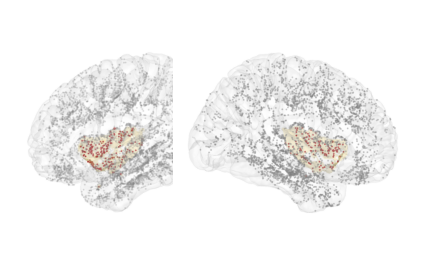

In [23]:
# cvs_avg35_inMNI152 visualization — template coords from package_ave_cord.py
# aparc labels for cortex validity; Hammers six-gyrus union for insula highlight
labels = mne.read_labels_from_annot(
    subject=FS_SUBJECT, parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir,
)

lh_brain = Brain(
    FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
    hemi='lh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600 * cm, 600 * cm),
)
rh_brain = Brain(
    FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
    hemi='rh', background='white', show=False,
    cortex=(0.9, 0.9, 0.9), alpha=0.1, size=(600 * cm, 600 * cm),
)

cord = coords_unique[['x', 'y', 'z']].values
insula_mask_arr = coords_unique['is_insula'].values

lh_pial_path = f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial'
rh_pial_path = f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial'
lh_coords_pial, _ = mne.read_surface(lh_pial_path)
rh_coords_pial, _ = mne.read_surface(rh_pial_path)
lh_tree = cKDTree(lh_coords_pial)
rh_tree = cKDTree(rh_coords_pial)

electrode_color = 'gray'
insula_electrode_color = red

mask_lh = cord[:, 0] < 0
mask_rh = cord[:, 0] > 0

if mask_lh.any():
    lh_cord = cord[mask_lh]
    lh_is_insula = insula_mask_arr[mask_lh]
    _, lh_indices = lh_tree.query(lh_cord)
    lh_projected_coords = lh_coords_pial[lh_indices]

    valid_mask = np.zeros(len(lh_cord), dtype=bool)
    for i, idx in enumerate(lh_indices):
        for lab in labels:
            if lab.hemi == 'lh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~lh_is_insula)
        insula_only = valid_mask & lh_is_insula
        if non_insula.any():
            cloud = pv.PolyData(lh_projected_coords[non_insula])
            lh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=electrode_color, lighting=False, smooth_shading=False, opacity=0.3,
            )
        if insula_only.any():
            cloud = pv.PolyData(lh_projected_coords[insula_only])
            lh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=insula_electrode_color, lighting=False, smooth_shading=False, opacity=0.9,
            )

if mask_rh.any():
    rh_cord = cord[mask_rh]
    rh_is_insula = insula_mask_arr[mask_rh]
    _, rh_indices = rh_tree.query(rh_cord)
    rh_projected_coords = rh_coords_pial[rh_indices]

    valid_mask = np.zeros(len(rh_cord), dtype=bool)
    for i, idx in enumerate(rh_indices):
        for lab in labels:
            if lab.hemi == 'rh' and idx in lab.vertices:
                valid_mask[i] = True
                break

    if valid_mask.any():
        non_insula = valid_mask & (~rh_is_insula)
        insula_only = valid_mask & rh_is_insula
        if non_insula.any():
            cloud = pv.PolyData(rh_projected_coords[non_insula])
            rh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=electrode_color, lighting=False, smooth_shading=False, opacity=0.5,
            )
        if insula_only.any():
            cloud = pv.PolyData(rh_projected_coords[insula_only])
            rh_brain._renderer.plotter.add_mesh(
                cloud, render_points_as_spheres=True, point_size=10,
                color=insula_electrode_color, lighting=False, smooth_shading=False, opacity=0.9,
            )

for lab in hammers_insula_highlight_labels:
    brain = lh_brain if lab.hemi == 'lh' else rh_brain
    brain.add_label(lab, borders=False, color=insula_color, alpha=0.5)

for brain in (lh_brain, rh_brain):
    brain.show_view(view='lateral', distance=400)
    brain._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(16 * cm, 8 * cm), gridspec_kw={'width_ratios': [1, 1]},
)
plt.subplots_adjust(wspace=-0.5)
ax1.imshow(lh_brain.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh_brain.screenshot(mode='rgb'))
ax2.axis('off')

lh_brain.close()
rh_brain.close()

fig.savefig('../img/fig1/fig1_all_electrodes_projected.svg', dpi=300, bbox_inches='tight')

# Panel B: Insula electrode zoom (L/R top-down)

Same insula-only mesh as Figure 2 on `cvs_avg35_inMNI152` pial. Contacts snap to the camera-facing insula wall (lateral view: MNE `elevation=90`) and are lifted toward the camera. Sampled insula electrodes (AIC/PIC, `mix==False`).

Gold = significant in any Repeat window (stimulus 0–1 s, delay 0–1 s, or response −0.5–0.5 s). Gray = sampled but not significant in those windows. Dashed contours are Hammers gyrus boundaries.


In [24]:
# Load per-timepoint HGA stats (mask column lives in *_time.csv)
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=str(hga_results_dir(t)),
            datatype='HGA',
            suffix='time',
            check=False,
        ).match()
    )

if not hga_paths:
    raise FileNotFoundError(
        f'No time CSVs under results/hga/{{task}}/ for tasks={task}'
    )

HGAs = pd.concat(
    [pd.read_csv(path) for path in tqdm(hga_paths, desc='load time')],
    ignore_index=True,
)

HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs['phase'] = HGAs['phase'].str.lower()

# Hammers ROI groupings (same convention as vizpub fig2)
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'STGp', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'STGa', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'

exclude_rois = {
    'Unknown', 'BrainStem', 'Thal', 'CC', 'Caud', 'Put', 'Amyg', 'Hipp',
    'LinG', 'Cun', 'mOccG', 'PhG', 'FuG', 'GRect', 'LatV', 'GSubcallosal',
    'Intersection', 'BrainStem–Thal',
}

phase_configs = {
    'stimulus': {'phase': 'stimulus', 'time_min': 0, 'time_max': 1},
    'delay': {'phase': 'delay', 'time_min': 0, 'time_max': 1},
    'response': {'phase': 'response', 'time_min': -0.5, 'time_max': 0.5},
}

ifg_color = blue


def filter_qc_electrodes(spatial):
    """Drop missing-annotation (label==0) and composite bipolar (mix) electrodes."""
    spatial = spatial.copy()
    if 'mix' in spatial.columns:
        spatial = spatial[~spatial['mix'].fillna(False).astype(bool)]
    if 'label' in spatial.columns:
        label_num = pd.to_numeric(spatial['label'], errors='coerce')
        spatial = spatial[~(label_num == 0)]
    return spatial


def _significant_spatial_for_phase(config):
    """Per-channel table for a phase/time window before QC/exclude filters."""
    mask = (
        (HGAs['phase'] == config['phase'])
        & (HGAs['description'] == 'Repeat')
        & (HGAs['time'] > config['time_min'])
        & (HGAs['time'] < config['time_max'])
        & (HGAs['mask'] == True)
    )
    return (
        HGAs[mask]
        .groupby('channel')
        .agg({'roi': 'first', 'mix': 'first', 'label': 'first'})
        .reset_index()
    )


def significant_channels_for_phase(config):
    """Unique significant channels in a phase/time window."""
    spatial = _significant_spatial_for_phase(config)
    spatial = filter_qc_electrodes(spatial)
    return spatial[~spatial.roi.isin(exclude_rois)].copy()


def phase_insula_vs_other():
    out = {}
    for phase_name, config in phase_configs.items():
        spatial = significant_channels_for_phase(config)
        insula_count = int(insula_mask(spatial, atlas).sum())
        total = len(spatial)
        out[phase_name] = {
            'insula': insula_count,
            'other': total - insula_count,
            'total': total,
        }
    return out


def phase_roi_breakdown():
    out = {}
    for phase_name, config in phase_configs.items():
        spatial = significant_channels_for_phase(config)
        spatial['category'] = np.select(
            [
                insula_mask(spatial, atlas),
                spatial['roi'] == 'STG',
                spatial['roi'] == 'SMC',
                spatial['roi'] == 'IFG',
            ],
            ['Insula', 'STG', 'SMC', 'IFG'],
            default='Other',
        )
        counts = spatial['category'].value_counts()
        out[phase_name] = {
            cat: int(counts.get(cat, 0))
            for cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']
        }
        out[phase_name]['total'] = len(spatial)
    return out


def significant_channels_union():
    """Unique significant channels active in any phase/time window."""
    frames = [
        significant_channels_for_phase(config)
        for config in phase_configs.values()
    ]
    return (
        pd.concat(frames, ignore_index=True)
        .drop_duplicates('channel')
        .reset_index(drop=True)
    )


def phase_insula_vs_other_union():
    spatial = significant_channels_union()
    insula_count = int(insula_mask(spatial, atlas).sum())
    total = len(spatial)
    return {'insula': insula_count, 'other': total - insula_count, 'total': total}


def phase_roi_breakdown_union():
    spatial = significant_channels_union()
    spatial['category'] = np.select(
        [
            insula_mask(spatial, atlas),
            spatial['roi'] == 'STG',
            spatial['roi'] == 'SMC',
            spatial['roi'] == 'IFG',
        ],
        ['Insula', 'STG', 'SMC', 'IFG'],
        default='Other',
    )
    counts = spatial['category'].value_counts()
    out = {
        cat: int(counts.get(cat, 0))
        for cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']
    }
    out['total'] = len(spatial)
    return out


def _remap_roi_column(df):
    spatial = df.copy()
    spatial.loc[spatial.roi == 'PrG', 'roi'] = 'SMC'
    spatial.loc[spatial.roi == 'PoG', 'roi'] = 'SMC'
    spatial.loc[spatial.roi == 'Subcentral', 'roi'] = 'SMC'
    spatial.loc[spatial.roi == 'STGp', 'roi'] = 'STG'
    spatial.loc[spatial.roi == 'STGa', 'roi'] = 'STG'
    spatial.loc[spatial.roi == 'HG', 'roi'] = 'STG'
    return spatial


def sampled_electrodes_spatial():
    """All unique sampled channels from coord CSVs (no mask filter), QC + exclude."""
    spatial = _remap_roi_column(coords_unique)
    spatial = filter_qc_electrodes(spatial)
    return spatial[~spatial.roi.isin(exclude_rois)].copy()


def sampling_roi_breakdown():
    spatial = sampled_electrodes_spatial()
    spatial['category'] = np.select(
        [
            insula_mask(spatial, atlas),
            spatial['roi'] == 'STG',
            spatial['roi'] == 'SMC',
            spatial['roi'] == 'IFG',
        ],
        ['Insula', 'STG', 'SMC', 'IFG'],
        default='Other',
    )
    counts = spatial['category'].value_counts()
    out = {
        cat: int(counts.get(cat, 0))
        for cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']
    }
    out['total'] = len(spatial)
    return out


def roi_significant_yield():
    """Per-ROI yield: significant_union / sampled (QC-filtered)."""
    sampled = sampling_roi_breakdown()
    significant = phase_roi_breakdown_union()
    category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
    out = {}
    for cat in category_order:
        n_sampled = sampled[cat]
        n_sig = significant[cat]
        out[cat] = {
            'sampled': n_sampled,
            'significant': n_sig,
            'yield_pct': 100.0 * n_sig / n_sampled if n_sampled else float('nan'),
        }
    out['total'] = {
        'sampled': sampled['total'],
        'significant': significant['total'],
        'yield_pct': (
            100.0 * significant['total'] / sampled['total']
            if sampled['total'] else float('nan')
        ),
    }
    return out


print('ROI mapping: STG <- {STGp, STGa, HG}; SMC <- {PrG, PoG, Subcentral}; IFG <- IFG')
print('QC filter: exclude label==0 and mix==True electrodes')
print('Per-phase QC counts (raw -> after QC -> final):')
for phase_name, config in phase_configs.items():
    spatial = _significant_spatial_for_phase(config)
    n_raw = len(spatial)
    spatial_qc = filter_qc_electrodes(spatial)
    n_qc = len(spatial_qc)
    n_final = len(spatial_qc[~spatial_qc.roi.isin(exclude_rois)])
    print(
        f'  {phase_name}: raw={n_raw} -> qc={n_qc} (-{n_raw - n_qc}) -> final={n_final}'
    )

union_raw = (
    pd.concat(
        [_significant_spatial_for_phase(cfg) for cfg in phase_configs.values()],
        ignore_index=True,
    )
    .drop_duplicates('channel')
)
n_union_raw = len(union_raw)
n_union_qc = len(filter_qc_electrodes(union_raw))
n_union_final = len(significant_channels_union())
print(
    f'Union QC counts: raw={n_union_raw} -> qc={n_union_qc} '
    f'(-{n_union_raw - n_union_qc}) -> final={n_union_final}'
)

print('Version 1:', phase_insula_vs_other())
print('Version 2:', phase_roi_breakdown())
print('Union v1:', phase_insula_vs_other_union())
print('Union v2:', phase_roi_breakdown_union())

_sampling_breakdown = sampling_roi_breakdown()
_sig_union_total = phase_roi_breakdown_union()['total']
print('Sampled electrodes (all tasks):', _sampling_breakdown)
print(
    f'Sampled vs significant union: '
    f'{_sampling_breakdown["total"]} sampled, {_sig_union_total} significant'
)

_yield_breakdown = roi_significant_yield()
print('Significant yield by ROI (% of sampled):')
for _cat in ['Insula', 'STG', 'SMC', 'IFG', 'Other']:
    _row = _yield_breakdown[_cat]
    print(
        f"  {_cat}: {_row['significant']}/{_row['sampled']} "
        f"({_row['yield_pct']:.1f}%)"
    )

sig_union_df = significant_channels_union()
sig_channels_union = set(sig_union_df['channel'])
print(f'Significant-union channels cached for Panel B: {len(sig_channels_union)}')


load time: 100%|██████████| 1632/1632 [04:05<00:00,  6.64it/s]


ROI mapping: STG <- {STGp, STGa, HG}; SMC <- {PrG, PoG, Subcentral}; IFG <- IFG
QC filter: exclude label==0 and mix==True electrodes
Per-phase QC counts (raw -> after QC -> final):
  stimulus: raw=5919 -> qc=2428 (-3491) -> final=2039
  delay: raw=4789 -> qc=2061 (-2728) -> final=1761
  response: raw=6837 -> qc=2580 (-4257) -> final=2281
Union QC counts: raw=8943 -> qc=3514 (-5429) -> final=2973
Version 1: {'stimulus': {'insula': 173, 'other': 1866, 'total': 2039}, 'delay': {'insula': 155, 'other': 1606, 'total': 1761}, 'response': {'insula': 209, 'other': 2072, 'total': 2281}}
Version 2: {'stimulus': {'Insula': 173, 'STG': 341, 'SMC': 179, 'IFG': 114, 'Other': 1232, 'total': 2039}, 'delay': {'Insula': 155, 'STG': 307, 'SMC': 164, 'IFG': 102, 'Other': 1033, 'total': 1761}, 'response': {'Insula': 209, 'STG': 328, 'SMC': 278, 'IFG': 110, 'Other': 1356, 'total': 2281}}
Union v1: {'insula': 272, 'other': 2701, 'total': 2973}
Union v2: {'Insula': 272, 'STG': 387, 'SMC': 304, 'IFG': 147, 'Ot

In [40]:
# Panel B helpers — insula-only mesh on cvs_avg35_inMNI152 pial (same as fig2)
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree

lh_pial_coords, lh_faces = mne.read_surface(
    f'{recon_dir}/{FS_SUBJECT}/surf/lh.pial'
)
rh_pial_coords, rh_faces = mne.read_surface(
    f'{recon_dir}/{FS_SUBJECT}/surf/rh.pial'
)
INSULA_MESH_COLOR = (0.9, 0.9, 0.9)
INSULA_MESH_ALPHA = 0.55
ELECTRODE_OFFSET_MM = 4.0
HAMMERS_FILL_MAX_MM = 8.0
POINT_SIZE_NSIG = 7
POINT_SIZE_SIG = 12
NSIG_COLOR = 'gray'

HAMMERS_GYRI = [
    'anterior pole',
    'anterior short gyrus',
    'middle short gyrus',
    'anterior long gyrus',
    'posterior short gyrus',
    'posterior long gyrus',
]
INSULA_PATTERNS = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]

labels = mne.read_labels_from_annot(
    subject=FS_SUBJECT, parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir,
)


def _insula_vertices(hemi):
    verts = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in INSULA_PATTERNS):
            verts.extend(lab.vertices)
    if not verts:
        raise RuntimeError(f'No insula labels for {hemi}')
    return np.unique(verts)


def _faces_to_polydata(coords, faces):
    faces_pv = np.hstack(
        [
            np.full((len(faces), 1), 3, dtype=np.int64),
            np.asarray(faces, dtype=np.int64),
        ]
    ).ravel()
    return pv.PolyData(np.asarray(coords, dtype=float), faces_pv)


def _insula_outward_normals(pial, faces, verts):
    """Area-weighted normals on insula vertices, flipped away from the centroid."""
    verts = np.asarray(verts)
    keep = np.all(np.isin(faces, verts), axis=1)
    ins_faces = np.asarray(faces[keep], dtype=np.int64)
    normals = np.zeros_like(pial, dtype=float)
    v0 = pial[ins_faces[:, 0]]
    v1 = pial[ins_faces[:, 1]]
    v2 = pial[ins_faces[:, 2]]
    face_n = np.cross(v1 - v0, v2 - v0)
    np.add.at(normals, ins_faces[:, 0], face_n)
    np.add.at(normals, ins_faces[:, 1], face_n)
    np.add.at(normals, ins_faces[:, 2], face_n)
    nrm = normals[verts]
    lengths = np.linalg.norm(nrm, axis=1, keepdims=True)
    valid = lengths[:, 0] > 1e-12
    nrm[valid] /= lengths[valid]
    centered = pial[verts] - pial[verts].mean(axis=0)
    nrm[np.einsum('ij,ij->i', nrm, centered) < 0] *= -1
    out = np.zeros_like(pial, dtype=float)
    out[verts] = nrm
    return out


def _prepare_insula_surface(hemi, pial, faces):
    """Insula mesh and per-vertex outward normals for later camera-facing snap."""
    verts = _insula_vertices(hemi)
    keep = np.all(np.isin(faces, verts), axis=1)
    ins_faces = np.asarray(faces[keep], dtype=np.int64)
    return {
        'mesh': _faces_to_polydata(pial, ins_faces),
        'faces': ins_faces,
        'center': pial[verts].mean(axis=0),
        'verts': verts,
        'normals': _insula_outward_normals(pial, faces, verts),
    }


lh_surf = _prepare_insula_surface('lh', lh_pial_coords, lh_faces)
rh_surf = _prepare_insula_surface('rh', rh_pial_coords, rh_faces)
lh_insula, lh_insula_center = lh_surf['mesh'], lh_surf['center']
rh_insula, rh_insula_center = rh_surf['mesh'], rh_surf['center']


def _hide_default_pial(brain):
    """Alpha=0 pial still writes the depth buffer and buries contacts."""
    collection = brain._renderer.plotter.renderer.GetActors()
    collection.InitTraversal()
    for _ in range(collection.GetNumberOfItems()):
        collection.GetNextActor().SetVisibility(False)


def _make_insula_brain(hemi):
    """Whole-hemisphere cortex hidden; only aparc.a2009s insula faces."""
    brain = Brain(
        FS_SUBJECT, subjects_dir=recon_dir, surf='pial',
        hemi=hemi, background='white', show=False,
        cortex=INSULA_MESH_COLOR, alpha=0.0, size=(800, 800),
    )
    _hide_default_pial(brain)
    mesh = lh_insula if hemi == 'lh' else rh_insula
    brain._renderer.plotter.add_mesh(
        mesh,
        color=INSULA_MESH_COLOR,
        opacity=INSULA_MESH_ALPHA,
        lighting=True,
        smooth_shading=True,
    )
    return brain


insula_electrodes = coords_unique.loc[coords_unique['is_insula']].copy()
insula_electrodes['is_significant'] = insula_electrodes['channel'].isin(
    sig_channels_union
)
n_sig = int(insula_electrodes['is_significant'].sum())
print(
    f'Insula electrodes for Panel B: {len(insula_electrodes)} sampled, '
    f'{n_sig} significant (Repeat, any of stimulus/delay/response)'
)


def _camera_xyz(brain):
    cam = brain._renderer.plotter.camera
    pos = cam.GetPosition() if hasattr(cam, 'GetPosition') else cam.position
    return np.asarray(pos, dtype=float)


def _project_to_insula(cord, surf, pial, camera_pos):
    """Snap to camera-facing insula vertices and lift toward the camera."""
    cam = np.asarray(camera_pos, dtype=float).reshape(1, 3)
    verts = surf['verts']
    xyz = pial[verts]
    nrm = surf['normals'][verts]
    to_cam = cam - xyz
    to_cam /= np.clip(np.linalg.norm(to_cam, axis=1, keepdims=True), 1e-6, None)
    facing = np.einsum('ij,ij->i', nrm, to_cam) > 0.0
    if int(facing.sum()) < 50:
        facing = np.ones(len(verts), dtype=bool)
    vis = verts[facing]
    _, idx = cKDTree(pial[vis]).query(cord)
    pts = pial[vis[idx]]
    lift = cam - pts
    lift /= np.clip(np.linalg.norm(lift, axis=1, keepdims=True), 1e-6, None)
    return pts + ELECTRODE_OFFSET_MM * lift


def _add_electrodes_fixed(brain, coords_proj, colors, point_sizes):
    for i, pt in enumerate(coords_proj):
        color = colors[i]
        if color is None or (isinstance(color, float) and np.isnan(color)):
            continue
        cloud = pv.PolyData(pt.reshape(1, 3))
        actor = brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=float(point_sizes[i]), color=color, lighting=False,
        )
        mapper = getattr(actor, 'mapper', None)
        if mapper is None and hasattr(actor, 'GetMapper'):
            mapper = actor.GetMapper()
        if mapper is not None and hasattr(
            mapper, 'SetResolveCoincidentTopologyToPolygonOffset'
        ):
            mapper.SetResolveCoincidentTopologyToPolygonOffset()


def _points_to_pixels(plotter, points, image_shape):
    pts = np.asarray(points, dtype=float)
    if pts.size == 0:
        return np.zeros((0, 2), dtype=float)
    if pts.ndim == 1:
        pts = pts.reshape(1, 3)
    if hasattr(plotter, 'project_points_to_pixels'):
        pix = np.asarray(plotter.project_points_to_pixels(pts), dtype=float)
        xy = np.asarray(pix[:, :2], dtype=float)
    else:
        import vtk

        renderer = plotter.renderer
        coordinate = vtk.vtkCoordinate()
        coordinate.SetCoordinateSystemToWorld()
        xy = np.zeros((len(pts), 2), dtype=float)
        for i, (x, y, z) in enumerate(pts):
            coordinate.SetValue(float(x), float(y), float(z))
            d = coordinate.GetComputedDisplayValue(renderer)
            xy[i] = (float(d[0]), float(d[1]))
    xy[:, 1] = (int(image_shape[0]) - 1) - xy[:, 1]
    return xy


def _hammers_gyrus_code(names):
    code = np.zeros(len(names), dtype=np.int8)
    for idx, gyrus in enumerate(HAMMERS_GYRI, start=1):
        code[names == gyrus] = idx
    return code


def _xy_arclength(xy):
    xy = np.asarray(xy, dtype=float)
    if len(xy) < 2:
        return 0.0
    return float(np.linalg.norm(np.diff(xy, axis=0), axis=1).sum())


def _pial_hammers_gyrus(pial, hemi):
    """Paint Destrieux insula verts by Hammers gyrus, filling pial/CSF holes."""
    img = nib.load(HAMMERS_MNI152_PATH)
    atlas_data = np.asarray(img.dataobj).squeeze()
    atlas_inv = np.linalg.inv(img.affine)
    cvs = _cvs_tkr_to_mni_ras(recon_dir, subject=FS_SUBJECT)
    ids = _sample_hammers_labels(
        pial, atlas_data, atlas_inv, cvs_tkr_to_mni=cvs,
    )
    hemi_ids = [
        atlas_idx for atlas_idx in HAMMERS_INSULA_IDS
        if ('lh' if atlas_idx % 2 == 0 else 'rh') == hemi
    ]
    verts = _insula_vertices(hemi)
    miss = ~np.isin(ids[verts], hemi_ids)
    if miss.any():
        mask = np.isin(atlas_data, hemi_ids)
        ijk = np.column_stack(np.where(mask))
        xyz = nib.affines.apply_affine(img.affine, ijk)
        mni_miss = nib.affines.apply_affine(cvs, pial[verts[miss]])
        dist, nn = cKDTree(xyz).query(mni_miss)
        filled = atlas_data[ijk[nn, 0], ijk[nn, 1], ijk[nn, 2]].astype(int)
        filled[dist > HAMMERS_FILL_MAX_MM] = 0
        ids[verts[miss]] = filled
    return np.array(
        [HAMMERS_INSULA_INDEX.get(int(i), '') for i in ids], dtype=object,
    )


def _render_insula_hemi(hemi, cord, colors, point_sizes):
    surf = lh_surf if hemi == 'lh' else rh_surf
    pial = lh_pial_coords if hemi == 'lh' else rh_pial_coords
    center = lh_insula_center if hemi == 'lh' else rh_insula_center
    azimuth = 180 if hemi == 'lh' else 0
    brain = _make_insula_brain(hemi)
    brain.show_view(
        azimuth=azimuth, elevation=90, distance=180, focalpoint=center,
    )
    if cord is not None and len(cord):
        proj = _project_to_insula(cord, surf, pial, _camera_xyz(brain))
        _add_electrodes_fixed(brain, proj, colors, point_sizes)
    plotter = brain._renderer.plotter
    for _ in range(2):
        plotter.render()
    img = np.asarray(brain.screenshot(mode='rgb'))

    def project(points):
        return _points_to_pixels(plotter, points, img.shape[:2])

    return img, project, brain


def plot_insula_electrode_panel(
    plot_df,
    *,
    colors,
    title,
    legend_handles=None,
    save_path=None,
    overlay_collect=None,
    point_sizes=None,
):
    """L/R insula-only pial with electrodes projected onto the surface."""
    if plot_df.empty:
        print(f'Skip plot (no electrodes): {title}')
        return

    cord = plot_df[['x', 'y', 'z']].values
    colors = np.asarray(colors, dtype=object)
    if point_sizes is None:
        point_sizes = np.full(len(plot_df), POINT_SIZE_SIG, dtype=float)
    else:
        point_sizes = np.asarray(point_sizes, dtype=float)
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0
    rendered = {}
    for hemi, mask in (('lh', mask_lh), ('rh', mask_rh)):
        xyz = cord[mask] if mask.any() else np.zeros((0, 3))
        col = colors[mask] if mask.any() else np.array([], dtype=object)
        sizes = point_sizes[mask] if mask.any() else np.array([], dtype=float)
        img, project, brain = _render_insula_hemi(hemi, xyz, col, sizes)
        overlay = overlay_collect(hemi, project) if overlay_collect else None
        brain.close()
        rendered[hemi] = (img, overlay)

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    for ax, hemi, title_hemi in (
        (axes[0], 'lh', 'Left Insula'),
        (axes[1], 'rh', 'Right Insula'),
    ):
        img, overlay = rendered[hemi]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(title_hemi, fontsize=fontsize)
        if overlay:
            for xy in overlay.get('lines_minor', []):
                if len(xy) < 2:
                    continue
                ax.plot(
                    xy[:, 0], xy[:, 1],
                    linestyle=(0, (2.4, 1.8)), color='0.40', lw=0.65,
                    solid_capstyle='round', dash_capstyle='butt',
                    zorder=5,
                )

    if legend_handles:
        axes[0].legend(
            handles=legend_handles,
            loc='upper left', fontsize=fontsize - 1, framealpha=0.9,
        )

    plt.suptitle(f'{title} (n={len(plot_df)})', fontsize=fontsize)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f'Saved {save_path}')

    plt.show()


lh_hammers_gyrus = _pial_hammers_gyrus(lh_pial_coords, 'lh')
rh_hammers_gyrus = _pial_hammers_gyrus(rh_pial_coords, 'rh')


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot
Insula electrodes for Panel B: 373 sampled, 271 significant (Repeat, any of stimulus/delay/response)


Sampled coords from: /hpc/group/coganlab/nanlinshi/insula/results/PhonemeSequence(bipolar)(hammers), /hpc/group/coganlab/nanlinshi/insula/results/LexicalDelay(bipolar)(hammers), /hpc/group/coganlab/nanlinshi/insula/results/LexicalNoDelay(bipolar)(hammers), /hpc/group/coganlab/nanlinshi/insula/results/PictureNaming(bipolar)(hammers)


load sig from same tree: 100%|██████████| 1491/1491 [00:47<00:00, 31.34it/s]


Panel B sampled insula: 358 (219 significant, 139 n.s.)
  lh: 76 n.s., 136 significant
  rh: 63 n.s., 83 significant
Saved ../img/fig1/fig1_insula_electrodes_gyrus_lines.svg


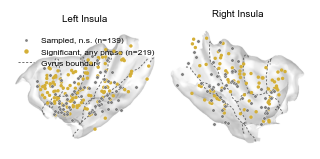

In [49]:
# Fig B5 — sampled vs significant insula electrodes + gyrus boundaries
# Significant = Repeat mask=True in any of stimulus / delay / response windows.
from collections import defaultdict
from scipy.ndimage import gaussian_filter1d


def _trace_boundary_network(pial, faces, code):
    """Create continuous label contours through triangle-edge midpoints."""
    xyz_by_node = {}
    segments = set()

    def edge_node(i, j):
        i, j = sorted((int(i), int(j)))
        key = ('edge', i, j)
        xyz_by_node[key] = 0.5 * (pial[i] + pial[j])
        return key

    for face_idx, f in enumerate(faces):
        crossed = []
        for i, j in ((f[0], f[1]), (f[1], f[2]), (f[2], f[0])):
            a, b = int(code[i]), int(code[j])
            if a > 0 and b > 0 and a != b:
                crossed.append(edge_node(i, j))

        if len(crossed) == 2:
            segments.add(frozenset((crossed[0], crossed[1])))
        elif len(crossed) == 3:
            center = ('face', int(face_idx))
            xyz_by_node[center] = pial[np.asarray(f, dtype=int)].mean(axis=0)
            for node in crossed:
                segments.add(frozenset((node, center)))

    adjacency = defaultdict(set)
    for segment in segments:
        a, b = tuple(segment)
        adjacency[a].add(b)
        adjacency[b].add(a)

    visited = set()

    def walk(start, nxt):
        path = [start, nxt]
        visited.add(frozenset((start, nxt)))
        previous, current = start, nxt
        while len(adjacency[current]) == 2:
            candidates = [
                node for node in adjacency[current]
                if node != previous
                and frozenset((current, node)) not in visited
            ]
            if not candidates:
                break
            following = candidates[0]
            visited.add(frozenset((current, following)))
            path.append(following)
            previous, current = current, following
        return path

    paths = []
    for node, neighbors in adjacency.items():
        if len(neighbors) == 2:
            continue
        for neighbor in neighbors:
            if frozenset((node, neighbor)) not in visited:
                paths.append(walk(node, neighbor))

    for segment in segments:
        if segment in visited:
            continue
        a, b = tuple(segment)
        paths.append(walk(a, b))

    return [
        np.asarray([xyz_by_node[node] for node in path], dtype=float)
        for path in paths
    ]


def _smooth_boundary(xyz, spacing=0.4, sigma_mm=1.8):
    """Resample and gently smooth one contour without moving its endpoints."""
    step = np.linalg.norm(np.diff(xyz, axis=0), axis=1)
    keep = np.concatenate([[True], step > 1e-6])
    xyz = np.asarray(xyz, dtype=float)[keep]
    if len(xyz) < 3:
        return xyz

    distance = np.concatenate([
        [0.0], np.cumsum(np.linalg.norm(np.diff(xyz, axis=0), axis=1))
    ])
    if distance[-1] <= spacing:
        return xyz
    sample_at = np.linspace(
        0.0, distance[-1], max(8, int(np.ceil(distance[-1] / spacing)))
    )
    sampled = np.column_stack([
        np.interp(sample_at, distance, xyz[:, axis]) for axis in range(3)
    ])
    smoothed = np.column_stack([
        gaussian_filter1d(
            sampled[:, axis], sigma=sigma_mm / spacing, mode='nearest'
        )
        for axis in range(3)
    ])
    smoothed[0] = sampled[0]
    smoothed[-1] = sampled[-1]
    return smoothed


def overlay_continuous_gyrus_boundaries(hemi, project):
    pial = lh_pial_coords if hemi == 'lh' else rh_pial_coords
    surf = lh_surf if hemi == 'lh' else rh_surf
    names = lh_hammers_gyrus if hemi == 'lh' else rh_hammers_gyrus
    code = _hammers_gyrus_code(names)

    lines = []
    for xyz in _trace_boundary_network(pial, surf['faces'], code):
        if len(xyz) < 3:
            continue
        xy = project(_smooth_boundary(xyz))
        if _xy_arclength(xy) >= 8:
            lines.append(xy)

    return {'lines_minor': lines}


# Sampled insula and significance must come from the same result tree.
# *_coord.csv = all zscore channels; *_time.csv mask = Repeat-window significance.
coord_keep = ['channel', 'subject', 'task', 'label', 'roi', 'hemi', 'x', 'y', 'z', 'mix']
time_keep = ['channel', 'description', 'phase', 'time', 'mask']
legacy_root = Path('..').resolve().parent / 'insula' / 'results'
coord_paths = []
coord_task_roots = []
for t in task:
    root = Path(hga_results_dir(t))
    found = BIDSPath(
        root=str(root), datatype='HGA', suffix='coord', check=False,
    ).match()
    if not found:
        root = legacy_root / f'{t}(bipolar)({atlas})'
        found = BIDSPath(
            root=str(root), datatype='HGA', suffix='coord', check=False,
        ).match()
    coord_task_roots.append(root)
    coord_paths.extend(found)
if not coord_paths:
    raise FileNotFoundError(
        'No *_coord.csv for sampled electrodes. '
        'Run src.hga.package_ave_cord before this panel.'
    )
print(
    'Sampled coords from: '
    + ', '.join(str(root) for root in coord_task_roots)
)

frames = []
for path in tqdm(coord_paths, desc='load sampled coords'):
    df = pd.read_csv(path, usecols=lambda c: c in coord_keep)
    frames.append(df)
sampled = (
    pd.concat(frames, ignore_index=True)
    .dropna(subset=['x', 'y', 'z'])
    .drop_duplicates('channel')
)
sampled_insula = filter_qc_electrodes(
    sampled.loc[insula_mask(sampled, atlas)].copy()
)

time_paths = []
for root in coord_task_roots:
    time_paths.extend(
        BIDSPath(
            root=str(root), datatype='HGA', suffix='time', check=False,
        ).match()
    )
if not time_paths:
    raise FileNotFoundError(
        'No *_time.csv next to sampled coords; cannot mark significance.'
    )

phase_windows = {
    'stimulus': (0.0, 1.0),
    'delay': (0.0, 1.0),
    'response': (-0.5, 0.5),
}
sig_from_same = set()
for path in tqdm(time_paths, desc='load sig from same tree'):
    df = pd.read_csv(path, usecols=lambda c: c in time_keep)
    if df.empty or 'mask' not in df.columns:
        continue
    df = df[(df['description'] == 'Repeat') & (df['mask'] == True)]
    if df.empty:
        continue
    phase = (
        df['phase'].astype(str).str.lower()
        .replace({'resp': 'response', 'audio': 'stimulus'})
    )
    keep = np.zeros(len(df), dtype=bool)
    times = df['time'].to_numpy()
    for name, (tmin, tmax) in phase_windows.items():
        keep |= (phase.to_numpy() == name) & (times > tmin) & (times < tmax)
    if keep.any():
        sig_from_same.update(df.loc[keep, 'channel'].astype(str))

sampled_insula['is_significant'] = sampled_insula['channel'].isin(
    sig_from_same
)
# Left-insula lateral outlier: AIC anterior pole, ~6 mm off the pial.
PANEL_B_EXCLUDE = {'D0122_LTAS1-2', 'D0076_LTP6-7'}
sampled_insula = sampled_insula[
    ~sampled_insula['channel'].isin(PANEL_B_EXCLUDE)
].copy()

# 3D spheres snap many contacts onto the same pial vertex, so gold hides black.
# Draw the mesh only, then scatter true x/y/z in 2D on the screenshot.
NSIG_COLOR = 'gray'
n_sig = int(sampled_insula['is_significant'].sum())
n_nsig = int((~sampled_insula['is_significant']).sum())
print(
    f'Panel B sampled insula: {len(sampled_insula)} '
    f'({n_sig} significant, {n_nsig} n.s.)'
)

legend_handles = [
    Line2D(
        [0], [0], marker='o', color='none',
        markerfacecolor=NSIG_COLOR, markeredgecolor='white',
        markersize=3, label=f'Sampled, n.s. (n={n_nsig})',
    ),
    Line2D(
        [0], [0], marker='o', color='none',
        markerfacecolor=insula_color, markeredgecolor='none',
        markersize=3.2, label=f'Significant, any phase (n={n_sig})',
    ),
    Line2D(
        [0], [0], color='0.40', lw=0.65,
        linestyle=(0, (2.4, 1.8)), label='Gyrus boundary',
    ),
]

empty_xyz = np.zeros((0, 3))
empty_col = np.array([], dtype=object)
empty_sz = np.array([], dtype=float)


def _crop_panel(img, xy, overlay, pad=24):
    """Trim screenshot whitespace; shift scatter and overlays (same as fig2)."""
    rgb = np.asarray(img)
    mask = np.any(rgb < 250, axis=2)
    if not mask.any():
        return rgb, np.asarray(xy, dtype=float), overlay
    ys, xs = np.nonzero(mask)
    y0 = max(0, int(ys.min()) - pad)
    y1 = min(rgb.shape[0], int(ys.max()) + 1 + pad)
    x0 = max(0, int(xs.min()) - pad)
    x1 = min(rgb.shape[1], int(xs.max()) + 1 + pad)
    xy_c = np.asarray(xy, dtype=float).copy()
    if xy_c.size:
        xy_c[:, 0] -= x0
        xy_c[:, 1] -= y0
    overlay_c = {
        'lines_minor': [
            np.column_stack([line[:, 0] - x0, line[:, 1] - y0])
            for line in overlay.get('lines_minor', [])
        ],
    }
    return rgb[y0:y1, x0:x1], xy_c, overlay_c


fig, axes = plt.subplots(1, 2, figsize=(8 * cm, 3.5 * cm))
for ax, hemi, title_hemi in (
    (axes[0], 'lh', 'Left Insula'),
    (axes[1], 'rh', 'Right Insula'),
):
    hemi_df = sampled_insula.loc[
        sampled_insula['x'] < 0 if hemi == 'lh' else sampled_insula['x'] > 0
    ]
    img, project, brain = _render_insula_hemi(
        hemi, empty_xyz, empty_col, empty_sz,
    )
    overlay = overlay_continuous_gyrus_boundaries(hemi, project)
    xyz = hemi_df[['x', 'y', 'z']].to_numpy()
    xy = project(xyz) if len(xyz) else np.zeros((0, 2))
    sig = hemi_df['is_significant'].to_numpy()
    brain.close()
    img, xy, overlay = _crop_panel(img, xy, overlay)

    ax.imshow(img)
    ax.set_xlim(0, img.shape[1])
    ax.set_ylim(img.shape[0], 0)
    ax.axis('off')
    ax.set_title(title_hemi, fontsize=fontsize)
    nsig = ~sig
    if sig.any():
        ax.scatter(
            xy[sig, 0], xy[sig, 1],
            s=6, c=insula_color, edgecolors='none', zorder=6,
        )
    if nsig.any():
        ax.scatter(
            xy[nsig, 0], xy[nsig, 1],
            s=6, c=NSIG_COLOR, edgecolors='white', linewidths=0.25,
            zorder=7,
        )
    for line_xy in overlay.get('lines_minor', []):
        if len(line_xy) < 2:
            continue
        ax.plot(
            line_xy[:, 0], line_xy[:, 1],
            linestyle=(0, (2.4, 1.8)), color='0.40', lw=0.65,
            solid_capstyle='round', dash_capstyle='butt', zorder=5,
        )
    print(
        f'  {hemi}: {int(nsig.sum())} n.s., {int(sig.sum())} significant'
    )

axes[0].legend(
    handles=legend_handles,
    loc='upper left', fontsize=fontsize - 1, frameon=False,
)
fig.subplots_adjust(wspace=0.02, left=0.02, right=0.98, top=0.92, bottom=0.02)
save_path = '../img/fig1/fig1_insula_electrodes_gyrus_lines.svg'
Path(save_path).parent.mkdir(parents=True, exist_ok=True)
fig.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved {save_path}')
plt.show()


### Insula laterality — significant / sampled

Same electrodes as Panel B. Left coverage is heavier, so raw L/R counts are not laterality. Each point is yield: significant *n* / sampled insula in that hemisphere. A slope would be a hemispheric bias; a flat line is bilateral recruitment after correcting sampling.

**Fisher exact** tests significant vs not-significant × Left vs Right (H0: yield_L = yield_R). Not a physiology laterality index.


sampled insula  L=212  R=146
significant     L=136  R=83
yield           L=0.642  R=0.568
Fisher exact  significant vs not × L vs R  p=0.19
Saved ../img/fig1/fig1_insula_laterality_yield.svg


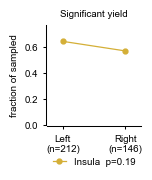

In [55]:
# Insula laterality: significant / sampled by hemisphere (same electrodes as Panel B).
from scipy.stats import fisher_exact

if 'sampled_insula' not in globals() or sampled_insula.empty:
    raise RuntimeError('Run the Panel B cell first (needs sampled_insula).')

lat = sampled_insula.dropna(subset=['x']).copy()
lat = lat[lat['x'] != 0]
lat['hemi'] = np.where(lat['x'] < 0, 'L', 'R')

n_samp = lat.groupby('hemi').size().reindex(['L', 'R'], fill_value=0)
n_sig = (
    lat.loc[lat['is_significant']]
    .groupby('hemi').size()
    .reindex(['L', 'R'], fill_value=0)
)
n_rate = n_sig / n_samp.replace(0, np.nan)

n_l = int(n_samp['L'])
n_r = int(n_samp['R'])
n_sig_l = int(n_sig['L'])
n_sig_r = int(n_sig['R'])
table = [
    [n_sig_l, n_sig_r],
    [n_l - n_sig_l, n_r - n_sig_r],
]
_, p_fisher = fisher_exact(table, alternative='two-sided')


def _fmt_p(p: float) -> str:
    if p < 0.001:
        return 'p<0.001'
    return f'p={p:.2f}'


print(f'sampled insula  L={n_l}  R={n_r}')
print(f'significant     L={n_sig_l}  R={n_sig_r}')
print(
    f'yield           L={float(n_rate["L"]):.3f}  '
    f'R={float(n_rate["R"]):.3f}'
)
print(
    'Fisher exact  significant vs not × L vs R  '
    f'{_fmt_p(p_fisher)}'
)

fig, ax = plt.subplots(figsize=(3.6 * cm, 4.4 * cm))
x = np.array([0.0, 1.0])
y_l = float(n_rate['L'])
y_r = float(n_rate['R'])
ax.plot(
    x, [y_l, y_r],
    '-o', color=insula_color, ms=3.5, lw=0.9,
    label=f'Insula  {_fmt_p(p_fisher)}',
)
ax.set_ylabel('fraction of sampled', fontsize=fontsize)
ax.set_title('Significant yield', fontsize=fontsize)
ax.set_xticks(x)
ax.set_xticklabels([f'Left\n(n={n_l})', f'Right\n(n={n_r})'])
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(0, max(0.4, max(y_l, y_r) * 1.2))
ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
plt.setp(ax.spines.values(), linewidth=0.75)
sns.despine(ax=ax, offset=1, trim=False)
ax.legend(
    frameon=False,
    fontsize=fontsize,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.28),
    handlelength=1.4,
    borderaxespad=0.0,
)
fig.subplots_adjust(left=0.30, right=0.96, bottom=0.32, top=0.90)
out = Path('../img/fig1/fig1_insula_laterality_yield.svg')
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out, format='svg', bbox_inches='tight')
print(f'Saved {out}')
plt.show()


## Significant HGA electrodes by phase

Time tables (`*_time.csv`) and union helpers were loaded before Panel B. Pie charts of **mask==True** electrodes (`description=='Repeat'`) in stimulus (0–1 s), delay (0–1 s), and response (−0.5–0.5 s) windows. Hammers atlas; insula = pure AIC+PIC with `mix==False`.


### Version 1 — Insula vs Other ROIs


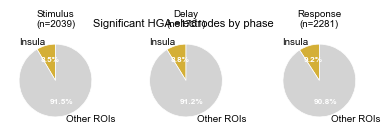

In [52]:
phase_data = phase_insula_vs_other()
max_count = max(data['total'] for data in phase_data.values())
widths = [
    np.sqrt(phase_data[phase]['total'] / max_count)
    for phase in ['stimulus', 'delay', 'response']
]

fig = plt.figure(figsize=(12 * cm, 3 * cm))
gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.35)

for idx, (phase_name, data) in enumerate(phase_data.items()):
    ax = fig.add_subplot(gs[idx])
    sizes = [data['insula'], data['other']]
    labels = ['Insula', 'Other ROIs']
    colors = [insula_color, 'lightgray']

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(6)

    ax.set_title(f'{phase_name.capitalize()}\n(n={data["total"]})', fontsize=fontsize)

plt.suptitle('Significant HGA electrodes by phase', fontsize=8, y=1.02)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_phase_insula_vs_other.svg', dpi=300, bbox_inches='tight')
plt.show()

### Version 2 — Insula + STG + SMC + IFG + Other


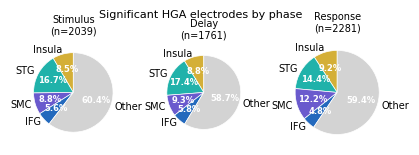

In [ ]:
breakdown_data = phase_roi_breakdown()
max_count = max(data['total'] for data in breakdown_data.values())
widths = [
    np.sqrt(breakdown_data[phase]['total'] / max_count)
    for phase in ['stimulus', 'delay', 'response']
]

category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

fig = plt.figure(figsize=(12 * cm, 4 * cm))
gs = fig.add_gridspec(1, 3, width_ratios=widths, wspace=0.35)

for idx, (phase_name, data) in enumerate(breakdown_data.items()):
    ax = fig.add_subplot(gs[idx])
    sizes = [data[cat] for cat in category_order]
    labels = category_order
    colors = [category_colors[cat] for cat in category_order]

    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )

    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(6)

    ax.set_title(f'{phase_name.capitalize()}\n(n={data["total"]})', fontsize=fontsize)

plt.suptitle('Significant HGA electrodes by phase', fontsize=8, y=1.02)
fig.savefig('../img/fig1/fig1_phase_roi_breakdown.svg', dpi=300, bbox_inches='tight')
plt.show()

### Union across phases — significant in any phase

Single pie chart: electrode is **active** if `mask==True` in stimulus, delay, or response (union across phases).


Union Insula vs Other: {'insula': 272, 'other': 2701, 'total': 2973}
Union ROI breakdown: {'Insula': 272, 'STG': 387, 'SMC': 304, 'IFG': 147, 'Other': 1863, 'total': 2973}


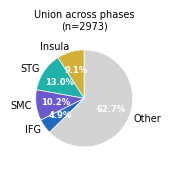

In [ ]:
union_breakdown = phase_roi_breakdown_union()
union_insula_other = phase_insula_vs_other_union()
print('Union Insula vs Other:', union_insula_other)
print('Union ROI breakdown:', union_breakdown)

category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

fig, ax = plt.subplots(figsize=(4 * cm, 4 * cm))
sizes = [union_breakdown[cat] for cat in category_order]
wedges, texts, autotexts = ax.pie(
    sizes,
    labels=category_order,
    colors=[category_colors[cat] for cat in category_order],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': fontsize},
    wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(6)
ax.set_title(
    f'Union across phases\n(n={union_breakdown["total"]})',
    fontsize=fontsize,
)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_phase_roi_breakdown_union.svg', dpi=300, bbox_inches='tight')
plt.show()

### Sampled electrode coverage by ROI

Same ROI grouping as the significant pie. **Top:** share of all significant electrodes. **Bottom:** share of all sampled electrodes (coord CSVs, no `mask==True`). Same QC (`label==0`, `mix==True` excluded).


Significant ROI breakdown: {'Insula': 272, 'STG': 387, 'SMC': 304, 'IFG': 147, 'Other': 1863, 'total': 2973}
Sampled ROI breakdown: {'Insula': 298, 'STG': 402, 'SMC': 332, 'IFG': 166, 'Other': 2101, 'total': 3299}
Saved ../img/fig1/fig1_roi_breakdown_sig_and_sampled.svg


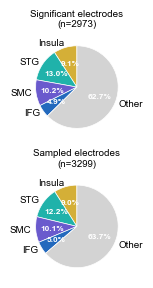

In [54]:
union_breakdown = phase_roi_breakdown_union()
sampling_breakdown = sampling_roi_breakdown()
print('Significant ROI breakdown:', union_breakdown)
print('Sampled ROI breakdown:', sampling_breakdown)

category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}


def _draw_roi_pie(ax, counts, title):
    sizes = [counts[cat] for cat in category_order]
    wedges, texts, autotexts = ax.pie(
        sizes,
        labels=category_order,
        colors=[category_colors[cat] for cat in category_order],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': fontsize},
        wedgeprops={'linewidth': 0.5, 'edgecolor': 'white'},
    )
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(6)
    ax.set_title(f'{title}\n(n={counts["total"]})', fontsize=fontsize)


fig, axes = plt.subplots(2, 1, figsize=(4 * cm, 8 * cm))
_draw_roi_pie(axes[0], union_breakdown, 'Significant electrodes')
_draw_roi_pie(axes[1], sampling_breakdown, 'Sampled electrodes')
fig.subplots_adjust(hspace=0.35)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig(
    '../img/fig1/fig1_roi_breakdown_sig_and_sampled.svg',
    dpi=300, bbox_inches='tight',
)
print('Saved ../img/fig1/fig1_roi_breakdown_sig_and_sampled.svg')
plt.show()


### Significant yield by ROI

Among **sampled** electrodes (QC filtered), fraction with significant HGA in any phase. Addresses whether smaller Insula share in the union pie reflects lower sampling vs lower activation rate.


category  sampled  significant yield_pct
  Insula      298          272     91.3%
     STG      402          387     96.3%
     SMC      332          304     91.6%
     IFG      166          147     88.6%
   Other     2101         1863     88.7%


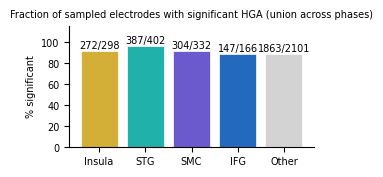

In [ ]:
yield_breakdown = roi_significant_yield()
category_order = ['Insula', 'STG', 'SMC', 'IFG', 'Other']
category_colors = {
    'Insula': insula_color,
    'STG': stg_color,
    'SMC': smc_color,
    'IFG': ifg_color,
    'Other': 'lightgray',
}

yield_table = pd.DataFrame(
    [
        {
            'category': cat,
            'sampled': yield_breakdown[cat]['sampled'],
            'significant': yield_breakdown[cat]['significant'],
            'yield_pct': yield_breakdown[cat]['yield_pct'],
        }
        for cat in category_order
    ]
)
print(yield_table.to_string(index=False, formatters={'yield_pct': '{:.1f}%'.format}))

fig, ax = plt.subplots(figsize=(8 * cm, 4 * cm))
yields = [yield_breakdown[cat]['yield_pct'] for cat in category_order]
bars = ax.bar(
    category_order,
    yields,
    color=[category_colors[cat] for cat in category_order],
    edgecolor='white',
    linewidth=0.5,
)
for bar, cat in zip(bars, category_order):
    row = yield_breakdown[cat]
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{row['significant']}/{row['sampled']}",
        ha='center',
        va='bottom',
        fontsize=fontsize,
    )
ax.set_ylabel('% significant', fontsize=fontsize)
ax.set_title(
    'Fraction of sampled electrodes with significant HGA (union across phases)',
    fontsize=fontsize,
)
ax.tick_params(axis='both', labelsize=fontsize)
ax.set_ylim(0, max(yields) * 1.2 if yields else 100)
sns.despine(ax=ax)
Path('../img/fig1').mkdir(parents=True, exist_ok=True)
fig.savefig('../img/fig1/fig1_roi_significant_yield.svg', dpi=300, bbox_inches='tight')
plt.show()

## Insula electrode schematic

Native-subject shaft restored from `viz/fig1.ipynb` (commit `1908332`): D0064 left-hemisphere pial, gold insula, one shaft with Hammers AIC contacts highlighted. Two independent panels (overview + zoom); connecting lines are added in Adobe.


In [ ]:
# Native D0064 montage + Hammers AIC/PIC labels (viz/fig1.ipynb @ 1908332)
import re

sub = 'D0064'
subid = 'D64'
bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'
parc_path = (
    f'{bids_root}derivatives/parcellation/sub-{sub}/bipolar/sub-{sub}_hammers.csv'
)
parc = pd.read_csv(parc_path).set_index('name')

epoch_paths = BIDSPath(
    root=bids_root + 'derivatives/epoch(bipolar)',
    subject=sub,
    suffix='highgamma',
    datatype='epoch(band)(zscore)',
    extension='.h5',
    check=False,
)
epoch_path = epoch_paths.match()[0]
epochs = mne.read_epochs(epoch_path, preload=False, verbose=False)
montage = epochs.get_montage()
if montage is None:
    raise RuntimeError(f'No montage on {epoch_path}')

subj_coords = pd.DataFrame(montage.get_positions()['ch_pos']).T
subj_coords.columns = ['x', 'y', 'z']
subj_coords[['x', 'y', 'z']] *= 1000
subj_coords = subj_coords.join(parc[['roi', 'mix']], how='left')


def get_strip_prefix(ch_name):
    parts = str(ch_name).split('_', 1)
    if len(parts) == 2:
        subj_id, elec = parts
        alpha_prefix = re.match(r'[A-Za-z]+', elec)
        if alpha_prefix:
            return f'{subj_id}_{alpha_prefix.group()}'
    return ch_name


subj_coords['strip'] = [get_strip_prefix(ch) for ch in subj_coords.index]
insula_channels = subj_coords[subj_coords['roi'].isin(['AIC', 'PIC'])].index
insula_strips = subj_coords.loc[insula_channels, 'strip'].unique()
print('Strips containing insula electrodes:', insula_strips)

strip_electrodes = subj_coords[subj_coords['strip'].isin(insula_strips)].copy()
print(
    f'Total electrodes in insula strips: {len(strip_electrodes)} | '
    f"AIC: {(strip_electrodes.roi == 'AIC').sum()} | "
    f"PIC: {(strip_electrodes.roi == 'PIC').sum()} | "
    f"Other: {(~strip_electrodes.roi.isin(['AIC', 'PIC'])).sum()}"
)

Strips containing insula electrodes: ['D0064_LAI']
Total electrodes in insula strips: 15 | AIC: 5 | PIC: 0 | Other: 10


/hpc/home/ns458/coganlab/nanlinshi/tmp/ipykernel_1737651/498760338.py:21: RuntimeWarning: This filename (/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/derivatives/epoch(bipolar)/sub-D0064/epoch(band)(zscore)/sub-D0064_task-PhonemeSequence_proc-Delay_desc-Repeat_highgamma.h5) does not conform to MNE naming conventions. All epochs files should end with -epo.fif, -epo.fif.gz, _epo.fif or _epo.fif.gz
  epochs = mne.read_epochs(epoch_path, preload=False, verbose=False)


libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-09-17 20:04:08.597 (18301.437s) [    7F67016A3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x107784610): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open 

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot


libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-09-17 20:04:09.838 (18302.679s) [    7F67016A3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0xc985ba00): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot
Saved ../img/fig1/fig1_insula_electrode_schematic.svg


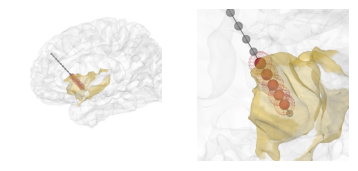

In [ ]:
# Ant-superior overview + zoom as two independent panels (link in Adobe).

INSULA_PATTERNS_NATIVE = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]
LABEL_RADIUS = 3
color_map = {'AIC': red, 'PIC': blue}


def _sort_strip(df):
    def _ch_num(name):
        match = re.search(r'(\d+)-\d+$', str(name))
        return int(match.group(1)) if match else 0
    return df.iloc[df.index.map(_ch_num).argsort()]


def build_insula_brain(hemi='lh', cortex_alpha=0.1):
    brain = Brain(
        subid, subjects_dir=recon_dir, surf='pial',
        hemi=hemi, background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=cortex_alpha, size=(800, 800),
    )
    labs = mne.read_labels_from_annot(
        subject=subid, parc='aparc.a2009s',
        surf_name='pial', hemi='both', subjects_dir=recon_dir,
    )
    for lab in labs:
        if any(p in lab.name for p in INSULA_PATTERNS_NATIVE) and lab.hemi == 'lh':
            brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)

    foci_hemi = 'lh' if hemi == 'both' else None
    for strip_name in insula_strips:
        strip_df = _sort_strip(strip_electrodes[strip_electrodes['strip'] == strip_name])
        coords_arr = strip_df[['x', 'y', 'z']].values
        rois = strip_df['roi'].values
        for coord, roi in zip(coords_arr, rois):
            is_ins = roi in ('AIC', 'PIC')
            foci_kwargs = dict(
                coords=coord[np.newaxis, :],
                scale_factor=0.3 if is_ins else 0.2,
                color=color_map.get(roi, 'gray'),
                alpha=1.0 if is_ins else 0.5,
            )
            if foci_hemi:
                foci_kwargs['hemi'] = foci_hemi
            brain.add_foci(**foci_kwargs)
            if is_ins:
                brain._renderer.plotter.add_mesh(
                    pv.Sphere(
                        radius=LABEL_RADIUS, center=coord,
                        theta_resolution=12, phi_resolution=12,
                    ),
                    style='wireframe',
                    color=color_map.get(roi, 'gray'),
                    line_width=0.5,
                    opacity=0.5,
                )
        if len(coords_arr) > 1:
            for j in range(len(coords_arr) - 1):
                brain._renderer.plotter.add_mesh(
                    pv.Line(coords_arr[j], coords_arr[j + 1]),
                    color='black', line_width=5, opacity=0.6,
                )
    return brain, labs


overview_brain, native_labels = build_insula_brain(hemi='lh', cortex_alpha=0.1)
zoom_brain, _ = build_insula_brain(hemi='lh', cortex_alpha=0.05)

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{subid}/surf/lh.pial')


def _native_insula_center(labs, pial_coords):
    vertices = []
    for lab in labs:
        if lab.hemi == 'lh' and any(p in lab.name for p in INSULA_PATTERNS_NATIVE):
            vertices.extend(lab.vertices)
    return pial_coords[vertices].mean(axis=0) if vertices else None


lh_insula_center = _native_insula_center(native_labels, lh_pial_coords)
aic_electrodes = strip_electrodes[strip_electrodes['roi'] == 'AIC']
aic_center = (
    aic_electrodes[['x', 'y', 'z']].values.mean(axis=0)
    if len(aic_electrodes) else lh_insula_center
)

overview_brain.show_view(
    azimuth=180, elevation=80, distance=320, focalpoint=lh_insula_center,
)
zoom_brain.show_view(
    azimuth=120, elevation=85, distance=100, focalpoint=aic_center,
)
overview = overview_brain.screenshot(mode='rgb')
zoom = zoom_brain.screenshot(mode='rgb')
overview_brain.close()
zoom_brain.close()

fig, axes = plt.subplots(1, 2, figsize=(12 * cm, 5 * cm))
for ax, img in zip(axes, (overview, zoom)):
    ax.imshow(img)
    ax.set_axis_off()
fig.subplots_adjust(wspace=0.04)

out_schematic = Path('../img/fig1/fig1_insula_electrode_schematic.svg')
out_schematic.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_schematic, dpi=300, bbox_inches='tight')
print(f'Saved {out_schematic}')
plt.show()

### SEEG shaft geometry (exploratory)

Keep the sphere schematic above. Physical contact rings from Hammers `x1/x2` endpoints; AIC rings red. Third panel is native `T1.mgz` sagittal slice through AIC; insula outline is MAPER Hammersmith (not Destrieux). Saved as `fig1_insula_electrode_schematic_seeg.svg`.


libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-09-17 20:05:08.641 (18361.481s) [    7F67016A3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x7474c7a0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 102: 10de:1e04, driver (null)

pci id for fd 106: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot


libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

2026-09-17 20:05:09.417 (18362.257s) [    7F67016A3740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x4c9c1bc0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: pci id for fd 106: 10de:1e04, driver (null)

pci id for fd 107: 10de:1e04, driver (null)
kmsro: driver missing
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /

Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/D64/label/rh.aparc.a2009s.annot
Saved ../img/fig1/fig1_insula_electrode_schematic_seeg.svg
D0064 LAI 3D | D0075 RAI T1 contacts 18 AIC 7 | T1 slice_x=38.50 actual=38.00 n_on_slice=7 window=19.0-111.0 fov=102x102mm insula_vox=992 hammers=(21, 87, 89, 91, 93, 95)


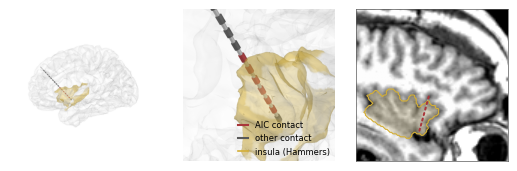

In [ ]:
# Physical SEEG rings. Does not overwrite the sphere schematic.
import re

INSULA_PATTERNS_NATIVE = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]

CONTACT_H = 2.0
TIP_EXTEND = 1.5
SKULL_EXTEND = 8.0
SCALE = {
    'overview': dict(shaft_r=0.45, ring_r=0.68, cortex_alpha=0.1),
    'zoom': dict(shaft_r=0.5, ring_r=0.8, cortex_alpha=0.05),
}


def _contact_num(name):
    match = re.search(r'(\d+)$', str(name))
    return int(match.group(1)) if match else 0


def lai_physical_geometry(parc_df, subject, strip='LAI', drop_mix=False):
    names = parc_df.index.astype(str)
    mask = names.str.match(rf'{subject}_{re.escape(strip)}\d')
    df = parc_df.loc[mask]
    contacts = {}
    pairs = []
    mix = df['mix'].astype(bool) if 'mix' in df.columns else pd.Series(False, index=df.index)
    for name, row in df.iterrows():
        c1, c2 = str(row['contact_1']), str(row['contact_2'])
        p1 = np.array([row['x1'], row['y1'], row['z1']], float)
        p2 = np.array([row['x2'], row['y2'], row['z2']], float)
        contacts[c1] = p1
        contacts[c2] = p2
        mixed = bool(mix.loc[name]) if drop_mix else False
        pairs.append({
            'name': str(name),
            'c1': c1,
            'c2': c2,
            'p1': p1,
            'p2': p2,
            'roi': row['roi'],
            'is_aic': (not mixed) and row['roi'] == 'AIC',
            'is_pic': (not mixed) and row['roi'] == 'PIC',
        })
    order = sorted(contacts, key=_contact_num)
    coords = np.vstack([contacts[c] for c in order])
    aic_contacts = {c for p in pairs if p['is_aic'] for c in (p['c1'], p['c2'])}
    pic_contacts = {c for p in pairs if p['is_pic'] for c in (p['c1'], p['c2'])}
    return order, coords, pairs, aic_contacts, pic_contacts


def _add_cylinder(plotter, p0, p1, radius, color, opacity=1.0):
    direction = np.asarray(p1, float) - np.asarray(p0, float)
    height = float(np.linalg.norm(direction))
    if height < 1e-6:
        return
    plotter.add_mesh(
        pv.Cylinder(
            center=(np.asarray(p0) + np.asarray(p1)) / 2.0,
            direction=direction,
            radius=radius,
            height=height,
            resolution=24,
        ),
        color=color,
        opacity=opacity,
        smooth_shading=True,
    )


def add_seeg_shaft(brain, order, coords, pairs, aic_contacts, pic_contacts, scale):
    plotter = brain._renderer.plotter
    shaft_r = scale['shaft_r']
    ring_r = scale['ring_r']
    axis = coords[-1] - coords[0]
    axis = axis / np.linalg.norm(axis)
    tip = coords[0] - axis * TIP_EXTEND
    skull = coords[-1] + axis * SKULL_EXTEND
    _add_cylinder(plotter, tip, skull, shaft_r, '#B8B8B8')
    plotter.add_mesh(
        pv.Sphere(radius=shaft_r, center=tip, theta_resolution=16, phi_resolution=16),
        color='#B8B8B8',
        smooth_shading=True,
    )
    for name, coord in zip(order, coords):
        if name in aic_contacts:
            color = red
        elif name in pic_contacts:
            color = blue
        else:
            color = '#595959'
        _add_cylinder(
            plotter,
            coord - axis * (CONTACT_H / 2.0),
            coord + axis * (CONTACT_H / 2.0),
            ring_r,
            color,
        )


def build_seeg_brain(scale_name):
    scale = SCALE[scale_name]
    brain = Brain(
        subid, subjects_dir=recon_dir, surf='pial',
        hemi='lh', background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=scale['cortex_alpha'], size=(800, 800),
    )
    labs = mne.read_labels_from_annot(
        subject=subid, parc='aparc.a2009s',
        surf_name='pial', hemi='both', subjects_dir=recon_dir,
    )
    for lab in labs:
        if any(p in lab.name for p in INSULA_PATTERNS_NATIVE) and lab.hemi == 'lh':
            brain.add_label(lab, borders=False, color=insula_color, alpha=0.6)
    order, coords, pairs, aic_contacts, pic_contacts = lai_physical_geometry(parc, sub)
    add_seeg_shaft(brain, order, coords, pairs, aic_contacts, pic_contacts, scale)
    return brain, labs, coords, pairs, aic_contacts


overview_brain, native_labels, seeg_coords, seeg_pairs, seeg_aic = build_seeg_brain('overview')
zoom_brain, _, _, _, _ = build_seeg_brain('zoom')

lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/{subid}/surf/lh.pial')
vertices = []
for lab in native_labels:
    if lab.hemi == 'lh' and any(p in lab.name for p in INSULA_PATTERNS_NATIVE):
        vertices.extend(lab.vertices)
lh_insula_center = lh_pial_coords[vertices].mean(axis=0) if vertices else seeg_coords.mean(axis=0)
aic_coords = np.vstack([
    pair['p1'] for pair in seeg_pairs if pair['is_aic']
] + [
    pair['p2'] for pair in seeg_pairs if pair['is_aic']
]) if any(p['is_aic'] for p in seeg_pairs) else seeg_coords
aic_center = aic_coords.mean(axis=0)
lh_hemi_center = lh_pial_coords.mean(axis=0)

overview_brain.show_view(
    azimuth=180, elevation=80, distance=420, focalpoint=lh_hemi_center,
)
zoom_brain.show_view(
    azimuth=120, elevation=85, distance=100, focalpoint=aic_center,
)
overview = overview_brain.screenshot(mode='rgb')
zoom = zoom_brain.screenshot(mode='rgb')
overview_brain.close()
zoom_brain.close()

import nibabel as nib

SLICE_TOL_MM = 4.0
IMG_SUB = 'D0075'
IMG_FSID = 'D75'
IMG_STRIP = 'RAI'
T1_PATH = Path(recon_dir) / IMG_FSID / 'mri' / 'T1.mgz'
MAPER_PATH = Path('/cwork/ns458/maper_run') / IMG_SUB / 'output' / f'f30-seg95-{IMG_SUB}.nii.gz'
# Hammers n30r95 insula, even=left / odd=right (slice_render.MAPER_INSULA_IDS)
HAMMERS_INSULA_LEFT = (20, 86, 88, 90, 92, 94)
HAMMERS_INSULA_RIGHT = (21, 87, 89, 91, 93, 95)


def sagittal_plane_tkr(img, x_mm):
    tkr = np.asarray(img.header.get_vox2ras_tkr(), dtype=float)
    vol = np.asarray(img.dataobj, dtype=float)
    index = int(np.round((x_mm - tkr[0, 3]) / tkr[0, 0]))
    index = int(np.clip(index, 0, vol.shape[0] - 1))
    sl = vol[index, ::-1, :]
    k0, k1 = -0.5, vol.shape[2] - 0.5
    j_bottom, j_top = vol.shape[1] - 0.5, -0.5
    extent = [
        float(tkr[1, 2] * k0 + tkr[1, 3]),
        float(tkr[1, 2] * k1 + tkr[1, 3]),
        float(tkr[2, 1] * j_bottom + tkr[2, 3]),
        float(tkr[2, 1] * j_top + tkr[2, 3]),
    ]
    actual_x = float(tkr[0, 0] * index + tkr[0, 3])
    return sl, extent, index, actual_x


def draw_lai_on_slice(ax, x0, order, coords, aic_contacts, pic_contacts, tol):
    half = 0.7
    axis = coords[-1] - coords[0]
    axis = axis / np.linalg.norm(axis)
    yz = np.array([axis[1], axis[2]], float)
    nrm = np.linalg.norm(yz)
    if nrm < 1e-6:
        return 0
    yz = yz / nrm
    near = np.abs(coords[:, 0] - x0) <= tol
    if near.sum() >= 2:
        pts = coords[near][:, 1:3]
        order_pts = np.argsort(pts[:, 1])
        ax.plot(
            pts[order_pts, 0], pts[order_pts, 1],
            color='#B8B8B8', lw=0.55, zorder=4, solid_capstyle='round',
        )
    n_drawn = 0
    for name, coord in zip(order, coords):
        if abs(coord[0] - x0) > tol:
            continue
        if name in aic_contacts:
            color = red
        elif name in pic_contacts:
            color = blue
        else:
            color = '#595959'
        ax.plot(
            [coord[1] - half * yz[0], coord[1] + half * yz[0]],
            [coord[2] - half * yz[1], coord[2] + half * yz[1]],
            color=color, lw=1.45, solid_capstyle='round', zorder=6,
        )
        n_drawn += 1
    return n_drawn


img_parc_path = (
    f'{bids_root}derivatives/parcellation/sub-{IMG_SUB}/bipolar/sub-{IMG_SUB}_hammers.csv'
)
img_parc = pd.read_csv(img_parc_path).set_index('name')
img_order, img_coords, img_pairs, img_aic, img_pic = lai_physical_geometry(
    img_parc, IMG_SUB, strip=IMG_STRIP, drop_mix=True,
)
img_focus = np.vstack(
    [img_coords[img_order.index(c)] for c in img_order if c in img_aic or c in img_pic]
) if (img_aic or img_pic) else img_coords
img_center = img_focus.mean(axis=0)
shaft_yz = img_coords[:, 1:3]
crop_center = shaft_yz.mean(axis=0)
half_yz = np.maximum(np.ptp(shaft_yz, axis=0) / 2.0 + 22.0, 42.0)
half = float(np.max(half_yz))
crop_xlim = (float(crop_center[0] - half), float(crop_center[0] + half))
crop_ylim = (float(crop_center[1] - half), float(crop_center[1] + half))
t1_img = nib.load(str(T1_PATH))
slice_x = float(img_center[0])
sl, extent, vox_i, actual_x = sagittal_plane_tkr(t1_img, slice_x)
yy = np.linspace(extent[0], extent[1], sl.shape[1])
zz = np.linspace(extent[2], extent[3], sl.shape[0])
Y, Z = np.meshgrid(yy, zz)
inside = (
    (Y >= crop_xlim[0]) & (Y <= crop_xlim[1])
    & (Z >= crop_ylim[0]) & (Z <= crop_ylim[1])
    & (sl > 0)
)
vals = sl[inside]
vmin = float(np.percentile(vals, 2)) if vals.size else 0.0
vmax = float(np.percentile(vals, 90)) if vals.size else float(sl.max() or 1.0)
if vmax <= vmin:
    vmax = vmin + 1.0
maper_img = nib.load(str(MAPER_PATH))
maper_sl = np.asarray(maper_img.dataobj).squeeze()[vox_i, ::-1, :].astype(int)
insula_ids = HAMMERS_INSULA_RIGHT if IMG_STRIP.startswith('R') else HAMMERS_INSULA_LEFT
insula_mask = np.isin(maper_sl, insula_ids)

fig, axes = plt.subplots(1, 3, figsize=(16.8 * cm, 5 * cm))
axes[0].imshow(overview)
axes[0].set_axis_off()
axes[1].imshow(zoom)
axes[1].set_axis_off()
axes[2].imshow(
    sl, origin='lower', extent=extent, cmap='gray',
    vmin=vmin, vmax=vmax, interpolation='bilinear', aspect='equal',
)
if np.any(insula_mask):
    axes[2].contourf(
        insula_mask.astype(float), levels=[0.5, 1.5], extent=extent,
        colors=[insula_color], alpha=0.14, origin='lower', zorder=2,
    )
    axes[2].contour(
        insula_mask.astype(float), levels=[0.5], extent=extent,
        colors=[insula_color], linewidths=0.8, origin='lower', zorder=5,
    )
n_slice = draw_lai_on_slice(
    axes[2], slice_x, img_order, img_coords, img_aic, img_pic, SLICE_TOL_MM,
)
axes[2].set_xlim(*crop_xlim)
axes[2].set_ylim(*crop_ylim)
axes[2].set_box_aspect(1)
axes[2].set_xticks([])
axes[2].set_yticks([])
for spine in axes[2].spines.values():
    spine.set_color('0.35')
    spine.set_linewidth(0.5)
fig.subplots_adjust(wspace=0.04)
axes[1].plot([], [], color=red, lw=1.5, label='AIC contact')
axes[1].plot([], [], color='#595959', lw=1.5, label='other contact')
axes[1].plot([], [], color=insula_color, lw=1.2, label='insula (Hammers)')
axes[1].legend(
    loc='lower right', fontsize=fontsize - 1, frameon=False,
    handlelength=1.2, borderaxespad=0.2,
)

out_seeg = Path('../img/fig1/fig1_insula_electrode_schematic_seeg.svg')
out_seeg.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_seeg, dpi=300, bbox_inches='tight')
print(f'Saved {out_seeg}')
print(
    f'D0064 LAI 3D | D0075 {IMG_STRIP} T1 contacts {len(img_coords)} AIC {len(img_aic)} | '
    f'T1 slice_x={slice_x:.2f} actual={actual_x:.2f} n_on_slice={n_slice} '
    f'window={vmin:.1f}-{vmax:.1f} fov={half*2:.0f}x{half*2:.0f}mm '
    f'insula_vox={int(insula_mask.sum())} hammers={insula_ids}'
)
plt.show()


## TFR — example AIC electrode

PhonemeSequence Repeat, D0088 AIC contact (`LAI3-4`). Stimulus / Delay / Response only — no Go. Loads the SHI-87 multitaper TFR (`results/tfr/`) and draws significant time–frequency clusters only (ratio → dB; cluster-corrected *p* < 0.05).

Saved ../img/fig1/fig1_example_electrode_tfr.svg from results/tfr (D0088 D0088_LAI3-4)


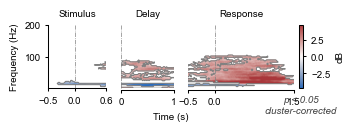

In [51]:
# Example AIC TFR from SHI-87 products (AF multitaper + cluster). No Go.
from src.tfr.run import channel_panels, load_phase_product

tfr_subject = "D0088"
tfr_task = "PhonemeSequence"
tfr_phases = ("Stimulus", "Delay", "Response")
plot_channel = "D0088_LAI3-4"
out_tfr = Path("../img/fig1/fig1_example_electrode_tfr.svg")
out_tfr.parent.mkdir(parents=True, exist_ok=True)

products = {}
for phase in tfr_phases:
    product = load_phase_product(tfr_subject, tfr_task, phase)
    if product is None:
        raise FileNotFoundError(
            f"Missing TFR H5 for {tfr_subject} {tfr_task} {phase}"
        )
    products[phase] = product
if plot_channel not in products[tfr_phases[0]]["ch_names"]:
    raise KeyError(f"{plot_channel} not in {tfr_task} TFR")

panels = channel_panels(products, plot_channel)
cluster_data = []
for phase in tfr_phases:
    panel = panels[phase]
    data = np.asarray(panel["data"], float).copy()
    significant = (np.asarray(panel["pvals"]) < 0.05) & (np.asarray(panel["mask"]) > 0)
    data[~significant] = np.nan
    panel["plot_data"] = data
    panel["significant"] = significant
    cluster_data.append(data.ravel())
stacked = np.concatenate(cluster_data)
vmin, vmax = np.nanpercentile(stacked, [5, 95]) if np.any(np.isfinite(stacked)) else (-1.0, 1.0)
limit = max(abs(float(vmin)), abs(float(vmax)))
if not np.isfinite(limit) or limit == 0:
    limit = 1.0
vmin, vmax = -limit, limit

# Same canvas as fig2 pooled insula traces so t=0 lines overlay in Illustrator.
TRACE_PHASES = ["stimulus", "delay", "response"]
FIG2_MARGINS = dict(left=0.16, right=0.94, wspace=0.2)
FIG2_TRACE_SIZE = (8 * cm, 3 * cm)
FIG2_TRACE_XLIMS = {
    "stimulus": (-0.5, 0.6),
    "delay": (0.0, 1.0),
    "response": (-0.5, 1.5),
}
FIG2_TRACE_XTICKS = {
    "stimulus": (-0.5, 0.0, 0.6),
    "delay": (0.0, 1.0),
    "response": (-0.5, 0.0, 1.5),
}

width_ratios = [hi - lo for lo, hi in (FIG2_TRACE_XLIMS[p] for p in TRACE_PHASES)]
fig = plt.figure(figsize=FIG2_TRACE_SIZE)
gs = fig.add_gridspec(
    nrows=1,
    ncols=len(TRACE_PHASES),
    width_ratios=width_ratios,
    wspace=FIG2_MARGINS["wspace"],
    left=FIG2_MARGINS["left"],
    right=FIG2_MARGINS["right"],
    bottom=0.28,
    top=0.82,
)
axes = [fig.add_subplot(gs[0, j]) for j in range(len(TRACE_PHASES))]

cmap = sns.color_palette("vlag", as_cmap=True)
mesh = None
for ax, phase in zip(axes, tfr_phases):
    panel = panels[phase]
    times = np.asarray(panel["times"], float)
    freqs = np.asarray(panel["freqs"], float)
    mesh = ax.pcolormesh(
        times, freqs, panel["plot_data"],
        shading="gouraud", cmap=cmap, rasterized=True,
        vmin=vmin, vmax=vmax,
    )
    if np.any(panel["significant"]):
        sig = np.zeros_like(panel["mask"])
        sig[panel["significant"]] = 1
        ax.contour(
            times, freqs, sig,
            levels=[0.8], colors="gray",
            linewidths=0.75, linestyles="-",
        )
    key = phase.lower()
    lo, hi = FIG2_TRACE_XLIMS[key]
    ax.set_title(phase, fontsize=fontsize)
    ax.set_xlim(lo, hi)
    ax.set_xticks(FIG2_TRACE_XTICKS[key])
    ax.set_ylim(4, 200)
    ax.axvline(0, color="gray", linestyle="-.", lw=0.5, clip_on=False)
    ax.set_xlabel("")
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which="both")
    plt.setp(ax.spines.values(), linewidth=0.75)
    if phase == "Stimulus":
        ax.set_ylabel("Frequency (Hz)", fontsize=fontsize)
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        ax.spines["left"].set_visible(True)
        ax.tick_params(axis="y", left=True, labelleft=True)
    else:
        ax.set_ylabel("")
        ax.set_yticks([])
        sns.despine(ax=ax, offset=1, trim=True)
        ax.spines["left"].set_visible(False)

# Colorbar in the unused right gutter so the three axes stay on the fig2 canvas.
cax = fig.add_axes([0.955, 0.28, 0.015, 0.54])
cbar = fig.colorbar(mesh, cax=cax)
cbar.set_label("dB", fontsize=fontsize)
cbar.ax.tick_params(labelsize=fontsize, width=0.75, length=2)
cbar.outline.set_linewidth(0.75)
fig.text(
    0.962, 0.22, "p < 0.05\ncluster-corrected",
    fontsize=fontsize, ha="center", va="top", color="0.25",
    fontstyle="italic", linespacing=1.2,
)

xmid = 0.5 * (FIG2_MARGINS["left"] + FIG2_MARGINS["right"])
fig.text(xmid, 0.08, "Time (s)", ha="center", va="top", fontsize=fontsize)

fig.savefig(out_tfr, format="svg", bbox_inches=None, pad_inches=0)
print(f"Saved {out_tfr} from results/tfr ({tfr_subject} {plot_channel})")
plt.show()
